In [ ]:
# RRCP (10/08/2026): PAC
"""
¿Qué se consigue con PCA?
	• Reducir la complejidad de los datos sin perder información crítica.
	• Visualizamos cluster y perfiles de jugadores de manera clara y rápida.
	• Crear una herramienta para tomar decisiones futbolisticas con visión técnica.

X
│
├── goles
├── asistencias
├── pases completados
└── tiros al arco
│
▼
StandardScaler
│
▼
X_scaled
│
├───────────────┐
│               │
▼               ▼
PCA           K-Means
│               │
▼               ▼
PC1 + PC2     Cluster
│               │
└───────┬───────┘
        ▼
   Visualización
"""
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
# Carar los datos
df_jugadores = pd.read_csv("../data/jugadores_cebollitas.csv")
X = df_jugadores[['goles','asistencias','pases_completados (%)', 'tiros_al_arco']]
df_jugadores.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   jugador_id             20 non-null     int64  
 1   nombre                 20 non-null     str    
 2   posición               20 non-null     str    
 3   edad                   20 non-null     int64  
 4   partidos_jugados       20 non-null     int64  
 5   goles                  20 non-null     int64  
 6   asistencias            20 non-null     int64  
 7   pases_completados (%)  20 non-null     float64
 8   tiros_al_arco          20 non-null     int64  
 9   precisión_tiros (%)    20 non-null     float64
 10  minutos_jugados        20 non-null     int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 1.8 KB


In [3]:
scaler = StandardScaler() # Crear una instancia de StandarScaler de scikit-learn.
"""
fit = aprende cómo transformar los datos.
transform = aplica esa transformación.
fit_transform = aprende y transforma en un solo paso.
"""
X_scaled = scaler.fit_transform(X) # Hace dos operaciones. (1) Aprende los parámetros de estandarización de X. (2) Transforma los dato usando esos parámetros.

In [4]:
"""
X_scaled tiene 4 variables:
X_scaled
    │
    ├── goles
    ├── asistencias
    ├── pases_completados (%)
    └── tiros_al_arco
Con "n_components = 2" se da la instrucción para reducir las 4 variables a solamente 2 nuevas variables,
intentando convervar la mayor cantidad posible de información.
Importante: los componentes principales no son directamente goles o asistencias. Son nuevas variables
creadas matemáticamente a partir de una combinación de las variables originales.
"""
pca = PCA(n_components = 2) # Instancia de objeto PCA con una configuración para conservar 2 componente principales.
"""
FIT:
PCA analiza las relaciones entre las cuatro variables y determina cuáles son las direcciones
que explican la mayor variabilidad de los datos.

TRANSFORM:
Despues de aprender con esos componentes, PCA transforma cada jugador desde el espacio original de 4 dimensiones:
    goles, asistencias, pases_completados y tiros_al_arco
a un espacio de solamente 2 dimensiones:
    Compenete 1 y Componente 2
"""
componentes = pca.fit_transform(X_scaled)

# A cotinuación se toman los dos componentes principales y se agregan a dos nuevas colu,nas.
df_jugadores['PC1'] = componentes[:,0] # Seleccionar todas las filas de la columna 0.
df_jugadores['PC2'] = componentes[:,1] # Seleccionar todas las filas de la columna 1.

<Axes: xlabel='PC1', ylabel='PC2'>

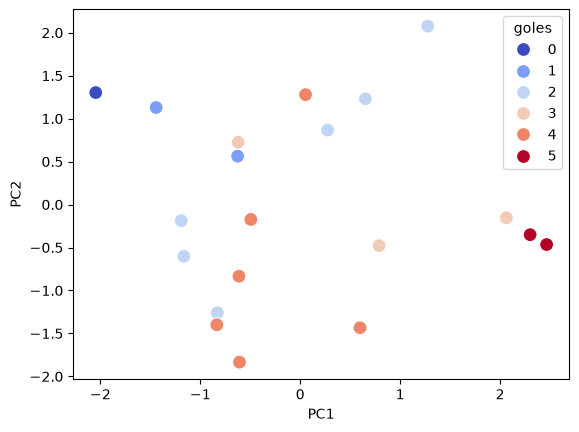

In [5]:
# Los jugadores que aparecen unos cerca de otros tienen caracteristicas estadisticas similares.
sns.scatterplot(
    x = 'PC1',  # Utilizar la columna PC1 como la coordenada del eje X.
    y = 'PC2',  # Utilizar la columna PC2 colo la coodenada del eje Y.
    data = df_jugadores, # Los datos que deben utilizarse están en el dataframe df_jugadores.
    hue = 'goles', # Se especifica la variable que se utilizará para diferenciar visualmente los puntos mediante colores.
    palette = 'coolwarm', # Paleta de colores.
    s = 100 # Tamaño de los puntos.
)

In [6]:
kmeans = KMeans(n_clusters = 3, random_state = 42) # Con KMeans encontrár los 3 grupos de jugadores.
# 1. Entrenar K-Means con los datos.
# 2. Asignar cada jugador a cada uno de los 3 cluster.
df_jugadores['cluster'] = kmeans.fit_predict(X_scaled) # 

<Axes: xlabel='PC1', ylabel='PC2'>

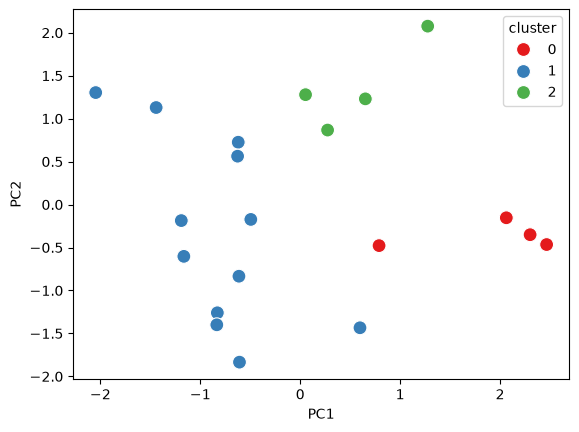

In [7]:
# Tomando como eje los compoentes principales se hace el diagrama de los clusters.
# Muéstrame en dónde está cada jugador en el espacio PCA y píntalo según el grupo que K-Means le asignó.
sns.scatterplot(
    x = 'PC1', 
    y = 'PC2', 
    hue = 'cluster', 
    palette = 'Set1',
    data = df_jugadores,
    s = 100
    )

In [10]:
"""
Explicar la varianza de cada componente es una de las partmes más importantes de PCA,
porque permite saber cuánta información está conservando al reducir la dimensionalidad.
Esto se necesita porque reducir la dimensionalidad siempre representa pérdida de información.

Como se podrá ver a continuación, el PCA explica el 67.04% de los datos originales.

Variabilidad original = 100%

PC1  ███████████████████  38.65%
PC2  ██████████████       28.39%
     ─────────────────────────
                          67.04%

No representado          32.96%
"""

varianza = pca.explained_variance_ratio_

print(f"Varianza explicada por PC1: {varianza[0]:.2%}")
print(f"Varianza explicada por PC2: {varianza[1]:.2%}")
print(f"Varianza total explicada: {varianza.sum():.2%}")

"""
Los dos primeros componentes principales explican el 67.04% de la variabilidad de las variables analizadas, por lo que la
representación bidimensional mediante PC1 y PC2 captura una parte importante de la estructura de los datos, aunque existe
un 32.96% de variabilidad que no está representada en estas dos dimensiones.
"""

Varianza explicada por PC1: 38.65%
Varianza explicada por PC2: 28.39%
Varianza total explicada: 67.04%


### Conclusión final para el ejercicio:
"La reducción dimensional mediante PCA a dos componentes permite representar el 67.04% de la variabilidad de los datos originales. Este porcentaje indica que PC1 y PC2 capturan una parte relevante de la estructura de los jugadores, aunque un 32.96% de la variabilidad queda fuera de la representación bidimensional. Por lo tanto, el gráfico PC1-PC2 es útil para visualizar los clusters, pero debe interpretarse como una representación parcial y no completa de los datos."

In [11]:
def explorar_componentes(eje_x, eje_y):
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=eje_x, y=eje_y, hue='cluster', data=df_jugadores, palette='Set2', s=100)
    plt.title(f'Clusters en espacio {eje_x} vs {eje_y}')
    plt.grid(True)
    plt.show()

widgets.interactive(
    explorar_componentes,
    eje_x=['PC1', 'PC2'],
    eje_y=['PC1', 'PC2']
)

interactive(children=(Dropdown(description='eje_x', options=('PC1', 'PC2'), value='PC1'), Dropdown(description…